In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── VEHICLE PARAMETERS (from Mercedes brief) ──
mu        = 1.7          # coefficient of friction
mass      = 798          # kg (F1 car without driver ~798kg, within 850 limit)
g         = 9.81         # m/s²
rho       = 1.225        # kg/m³ air density
Cl        = 2.2          # lift coefficient (downforce)
Cd        = 0.9          # drag coefficient
A         = 1.0          # frontal area m²
P_max     = 500_000      # watts (500 kW)

print("Parameters loaded successfully")
print(f"Car mass: {mass} kg")
print(f"Max power: {P_max/1000} kW")
print(f"Friction coefficient: {mu}")

Parameters loaded successfully
Car mass: 798 kg
Max power: 500.0 kW
Friction coefficient: 1.7


In [2]:
import urllib.request
import os

# Download Silverstone track data from the racing database Jaden referenced
url = "https://raw.githubusercontent.com/TUMFTM/racetrack-database/master/tracks/Silverstone.csv"
filename = "Silverstone.csv"

urllib.request.urlretrieve(url, filename)

# Load it
data = np.genfromtxt(filename, delimiter=',', skip_header=1)

# Extract columns: x, y, width_right, width_left, curvature
x        = data[:, 0]
y        = data[:, 1]
curvature = data[:, 4]

# Compute distance along track
dx = np.diff(x)
dy = np.diff(y)
ds = np.sqrt(dx**2 + dy**2)
distance = np.concatenate(([0], np.cumsum(ds)))

print(f"Track points loaded: {len(distance)}")
print(f"Track length: {distance[-1]:.1f} m")
print(f"Max curvature: {np.max(np.abs(curvature)):.4f} 1/m")


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

In [3]:
import ssl
import urllib.request

# Fix Mac SSL certificate issue
ssl._create_default_https_context = ssl._create_unverified_context

# Now download Silverstone track data
url = "https://raw.githubusercontent.com/TUMFTM/racetrack-database/master/tracks/Silverstone.csv"
filename = "Silverstone.csv"

urllib.request.urlretrieve(url, filename)

# Load it
data = np.genfromtxt(filename, delimiter=',', skip_header=1)

# Extract columns: x, y, width_right, width_left, curvature
x         = data[:, 0]
y         = data[:, 1]
curvature = data[:, 4]

# Compute distance along track
dx = np.diff(x)
dy = np.diff(y)
ds = np.sqrt(dx**2 + dy**2)
distance = np.concatenate(([0], np.cumsum(ds)))

print(f"Track points loaded: {len(distance)}")
print(f"Track length: {distance[-1]:.1f} m")
print(f"Max curvature: {np.max(np.abs(curvature)):.4f} 1/m")


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

In [4]:
import os
print(os.getcwd())

/Users/ilzepolekauskaite


In [5]:
data = np.genfromtxt('/Users/ilzepolekauskaite/Silverstone.csv', delimiter=',', skip_header=1)

# Extract columns: x, y, width_right, width_left, curvature
x         = data[:, 0]
y         = data[:, 1]
curvature = data[:, 4]

# Compute distance along track
dx = np.diff(x)
dy = np.diff(y)
ds = np.sqrt(dx**2 + dy**2)
distance = np.concatenate(([0], np.cumsum(ds)))

print(f"Track points loaded: {len(distance)}")
print(f"Track length: {distance[-1]:.1f} m")
print(f"Max curvature: {np.max(np.abs(curvature)):.4f} 1/m")

IndexError: index 4 is out of bounds for axis 1 with size 4

In [6]:
# Check what the file actually contains
with open('/Users/ilzepolekauskaite/Silverstone.csv', 'r') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i > 3:
            break

# x_m,y_m,w_tr_right_m,w_tr_left_m
3.439354,-0.495322,6.556,6.536
6.370784,3.555763,6.558,6.537
9.301950,7.606888,6.560,6.538
12.232871,11.658055,6.562,6.539


In [7]:
data = np.genfromtxt('/Users/ilzepolekauskaite/Silverstone.csv', delimiter=',', skip_header=1)

x = data[:, 0]
y = data[:, 1]

# Compute distance along track
dx = np.diff(x)
dy = np.diff(y)
ds = np.sqrt(dx**2 + dy**2)
distance = np.concatenate(([0], np.cumsum(ds)))

# Calculate curvature from x,y coordinates
# κ = |x'y'' - y'x''| / (x'^2 + y'^2)^1.5
dx  = np.gradient(x)
dy  = np.gradient(y)
ddx = np.gradient(dx)
ddy = np.gradient(dy)
curvature = np.abs(dx*ddy - dy*ddx) / (dx**2 + dy**2)**1.5

print(f"Track points loaded: {len(distance)}")
print(f"Track length: {distance[-1]:.1f} m")
print(f"Max curvature: {np.max(curvature):.4f} 1/m")

Track points loaded: 1178
Track length: 5881.8 m
Max curvature: 0.0767 1/m


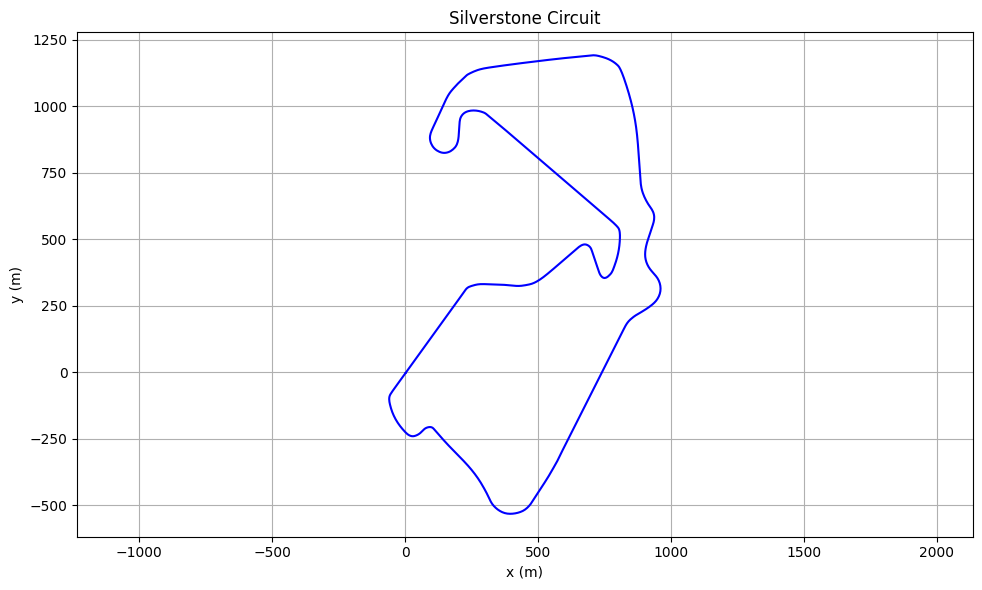

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=1.5)
plt.title('Silverstone Circuit')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# ── MAXIMUM CORNERING SPEED ──
# At each point, the car is limited by friction + downforce
# Downforce increases normal force: N = mg + 0.5*rho*Cl*A*v²
# Friction limit: mu * N = m * v² * kappa
# Solving for v: mu*(mg + 0.5*rho*Cl*A*v²) = m*kappa*v²
# v² = mu*m*g / (m*kappa - 0.5*mu*rho*Cl*A)

# Avoid division by zero on straights (very low curvature)
kappa = np.maximum(curvature, 1e-6)

numerator   = mu * mass * g
denominator = mass * kappa - 0.5 * mu * rho * Cl * A

# Where denominator <= 0, speed is unconstrained (straight)
v_corner = np.where(denominator > 0, 
                    np.sqrt(np.maximum(numerator / denominator, 0)),
                    200.0)  # cap straights at 200 m/s

# Convert to km/h for sanity check
print(f"Min cornering speed: {np.min(v_corner)*3.6:.1f} km/h")
print(f"Max cornering speed: {np.max(v_corner[v_corner < 200])*3.6:.1f} km/h")
print(f"Slowest corner at distance: {distance[np.argmin(v_corner)]:.0f} m")

Min cornering speed: 54.1 km/h
Max cornering speed: 708.2 km/h
Slowest corner at distance: 1044 m


In [10]:
# ── FORWARD-BACKWARD PROPAGATION ──

n = len(distance)
v = np.zeros(n)

# Start from rest, we'll iterate to convergence
v = v_corner.copy()

# ── BACKWARD PASS (braking into corners) ──
for i in range(n-2, -1, -1):
    ds_step = distance[i+1] - distance[i]
    
    # Aero drag force
    drag = 0.5 * rho * Cd * A * v[i+1]**2
    
    # Downforce increases grip
    downforce = 0.5 * rho * Cl * A * v[i+1]**2
    normal_force = mass * g + downforce
    
    # Max braking deceleration
    a_brake = (mu * normal_force + drag) / mass  # drag helps braking
    
    # Max speed arriving at i given speed at i+1
    v_back = np.sqrt(v[i+1]**2 + 2 * a_brake * ds_step)
    v[i] = min(v[i], v_back)

# ── FORWARD PASS (accelerating out of corners) ──
for i in range(n-1):
    ds_step = distance[i+1] - distance[i]
    
    # Aero drag force
    drag = 0.5 * rho * Cd * A * v[i]**2
    
    # Downforce
    downforce = 0.5 * rho * Cl * A * v[i]**2
    normal_force = mass * g + downforce
    
    # Power limited traction force
    F_traction = min(P_max / max(v[i], 1.0), mu * normal_force)
    
    # Net acceleration
    a_fwd = (F_traction - drag) / mass
    
    # Max speed at next point
    v_fwd = np.sqrt(v[i]**2 + 2 * max(a_fwd, 0) * ds_step)
    v[i+1] = min(v[i+1], v_fwd)

# ── LAP TIME ──
# dt = ds / average_v
avg_v = (v[:-1] + v[1:]) / 2
dt = np.diff(distance) / np.maximum(avg_v, 1.0)
lap_time = np.sum(dt)

print(f"Lap time: {lap_time:.2f} seconds  ({int(lap_time//60)}:{lap_time%60:.2f})")
print(f"Max speed: {np.max(v)*3.6:.1f} km/h")
print(f"Min speed: {np.min(v)*3.6:.1f} km/h")
print(f"Avg speed: {np.mean(v)*3.6:.1f} km/h")

Lap time: 111.20 seconds  (1:51.20)
Max speed: 720.0 km/h
Min speed: 54.1 km/h
Avg speed: 223.1 km/h


In [11]:
# ── CAP TOP SPEED ──
# At top speed, drive force = drag force
# P_max / v_top = 0.5 * rho * Cd * A * v_top²
# Solve: v_top³ = P_max / (0.5 * rho * Cd * A)
v_top = (P_max / (0.5 * rho * Cd * A))**(1/3)
print(f"Theoretical top speed: {v_top*3.6:.1f} km/h")

# Re-run with top speed cap
v = np.minimum(v_corner, v_top)

# BACKWARD PASS
for i in range(n-2, -1, -1):
    ds_step = distance[i+1] - distance[i]
    drag = 0.5 * rho * Cd * A * v[i+1]**2
    downforce = 0.5 * rho * Cl * A * v[i+1]**2
    normal_force = mass * g + downforce
    a_brake = (mu * normal_force + drag) / mass
    v_back = np.sqrt(v[i+1]**2 + 2 * a_brake * ds_step)
    v[i] = min(v[i], v_back)

# FORWARD PASS
for i in range(n-1):
    ds_step = distance[i+1] - distance[i]
    drag = 0.5 * rho * Cd * A * v[i]**2
    downforce = 0.5 * rho * Cl * A * v[i]**2
    normal_force = mass * g + downforce
    F_traction = min(P_max / max(v[i], 1.0), mu * normal_force)
    a_fwd = (F_traction - drag) / mass
    v_fwd = np.sqrt(v[i]**2 + 2 * max(a_fwd, 0) * ds_step)
    v[i+1] = min(v[i+1], v_fwd)

# LAP TIME
avg_v = (v[:-1] + v[1:]) / 2
dt = np.diff(distance) / np.maximum(avg_v, 1.0)
lap_time = np.sum(dt)

print(f"Lap time: {lap_time:.2f} seconds  ({int(lap_time//60)}:{lap_time%60:.2f})")
print(f"Max speed: {np.max(v)*3.6:.1f} km/h")
print(f"Min speed: {np.min(v)*3.6:.1f} km/h")
print(f"Avg speed: {np.mean(v)*3.6:.1f} km/h")

Theoretical top speed: 348.5 km/h
Lap time: 112.17 seconds  (1:52.17)
Max speed: 348.5 km/h
Min speed: 54.1 km/h
Avg speed: 212.7 km/h


NameError: name 'ax' is not defined

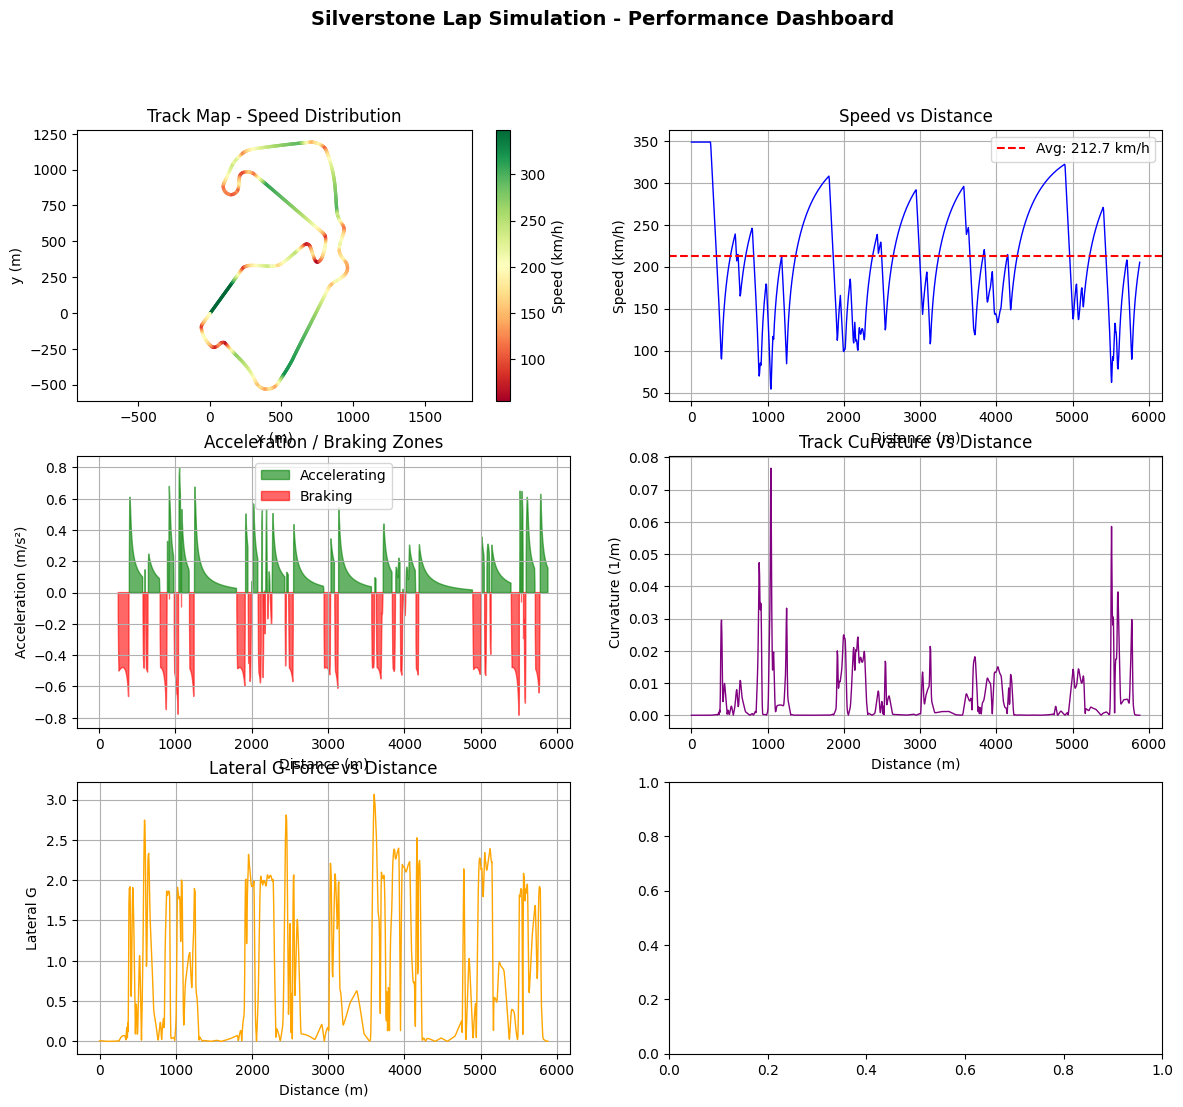

In [12]:
# ── PHASE 2: DATA VIEWER ──

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Silverstone Lap Simulation - Performance Dashboard', 
             fontsize=14, fontweight='bold')

# 1. Track map coloured by speed
ax1 = axes[0, 0]
sc = ax1.scatter(x, y, c=v*3.6, cmap='RdYlGn', s=2)
plt.colorbar(sc, ax=ax1, label='Speed (km/h)')
ax1.set_title('Track Map - Speed Distribution')
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.axis('equal')

# 2. Speed vs distance
ax2 = axes[0, 1]
ax2.plot(distance, v*3.6, 'b-', linewidth=1)
ax2.set_title('Speed vs Distance')
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Speed (km/h)')
ax2.grid(True)
ax2.axhline(y=np.mean(v)*3.6, color='r', linestyle='--', label=f'Avg: {np.mean(v)*3.6:.1f} km/h')
ax2.legend()

# 3. Acceleration/braking zones
ax3 = axes[1, 0]
acceleration = np.gradient(v, distance)
ax3.fill_between(distance, acceleration, 0, 
                  where=acceleration>0, color='green', alpha=0.6, label='Accelerating')
ax3.fill_between(distance, acceleration, 0, 
                  where=acceleration<0, color='red', alpha=0.6, label='Braking')
ax3.set_title('Acceleration / Braking Zones')
ax3.set_xlabel('Distance (m)')
ax3.set_ylabel('Acceleration (m/s²)')
ax3.legend()
ax3.grid(True)

# 4. Curvature vs distance
ax4 = axes[1, 1]
ax4.plot(distance, curvature, 'purple', linewidth=1)
ax4.set_title('Track Curvature vs Distance')
ax4.set_xlabel('Distance (m)')
ax4.set_ylabel('Curvature (1/m)')
ax4.grid(True)

# 5. Lateral G-force
ax5 = axes[2, 0]
lateral_g = (v**2 * curvature) / g
ax5.plot(distance, lateral_g, 'orange', linewidth=1)
ax5.set_title('Lateral G-Force vs Distance')
ax5.set_xlabel('Distance (m)')
ax5.set_ylabel('Lateral G')
ax5.grid(True)

# 6. Sector time distribution
sector_size = len(dt) // 3
s1 = np.sum(dt[:sector_size])
s2 = np.sum(dt[sector_size:2*sector_size])
s3 = np.sum(dt[2*sector_size:])
ax6 = axes[2, 1]
ax

In [13]:
ax6.bar(['Sector 1', 'Sector 2', 'Sector 3'], [s1, s2, s3], 
        color=['blue', 'orange', 'green'])
ax6.set_title(f'Sector Times  (Total: {int(lap_time//60)}:{lap_time%60:.2f})')
ax6.set_ylabel('Time (s)')
for i, val in enumerate([s1, s2, s3]):
    ax6.text(i, val + 0.3, f'{val:.2f}s', ha='center', fontweight='bold')
ax6.grid(True, axis='y')

plt.tight_layout()
plt.savefig('silverstone_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as silverstone_dashboard.png")

<Figure size 640x480 with 0 Axes>

Dashboard saved as silverstone_dashboard.png


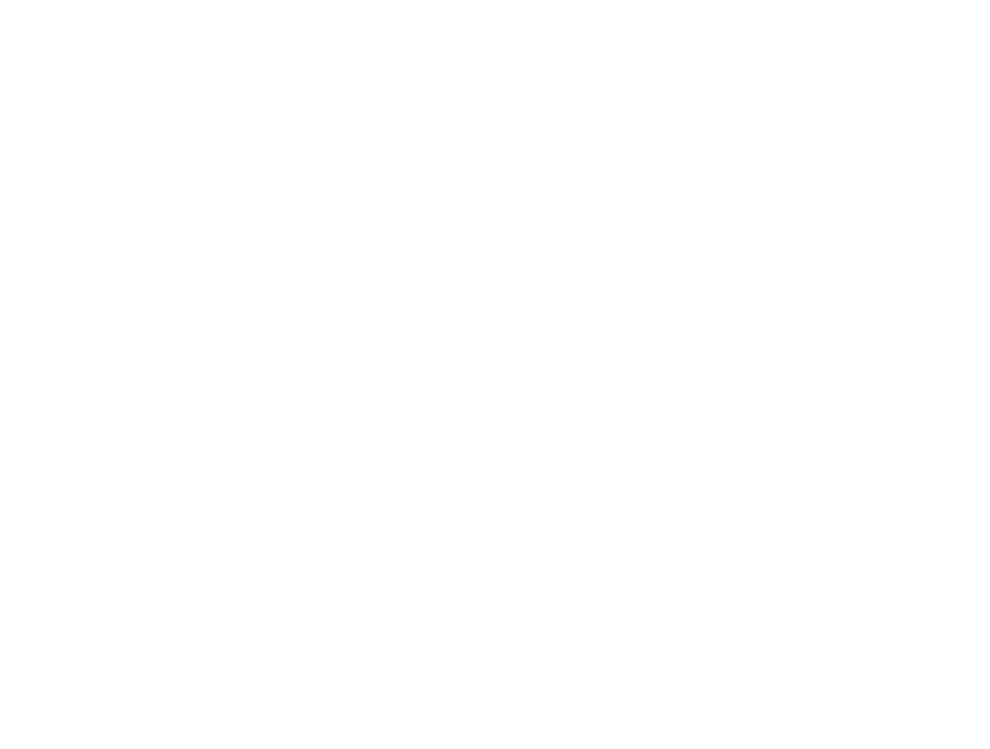

In [14]:
%matplotlib inline
from IPython.display import Image
Image('silverstone_dashboard.png')

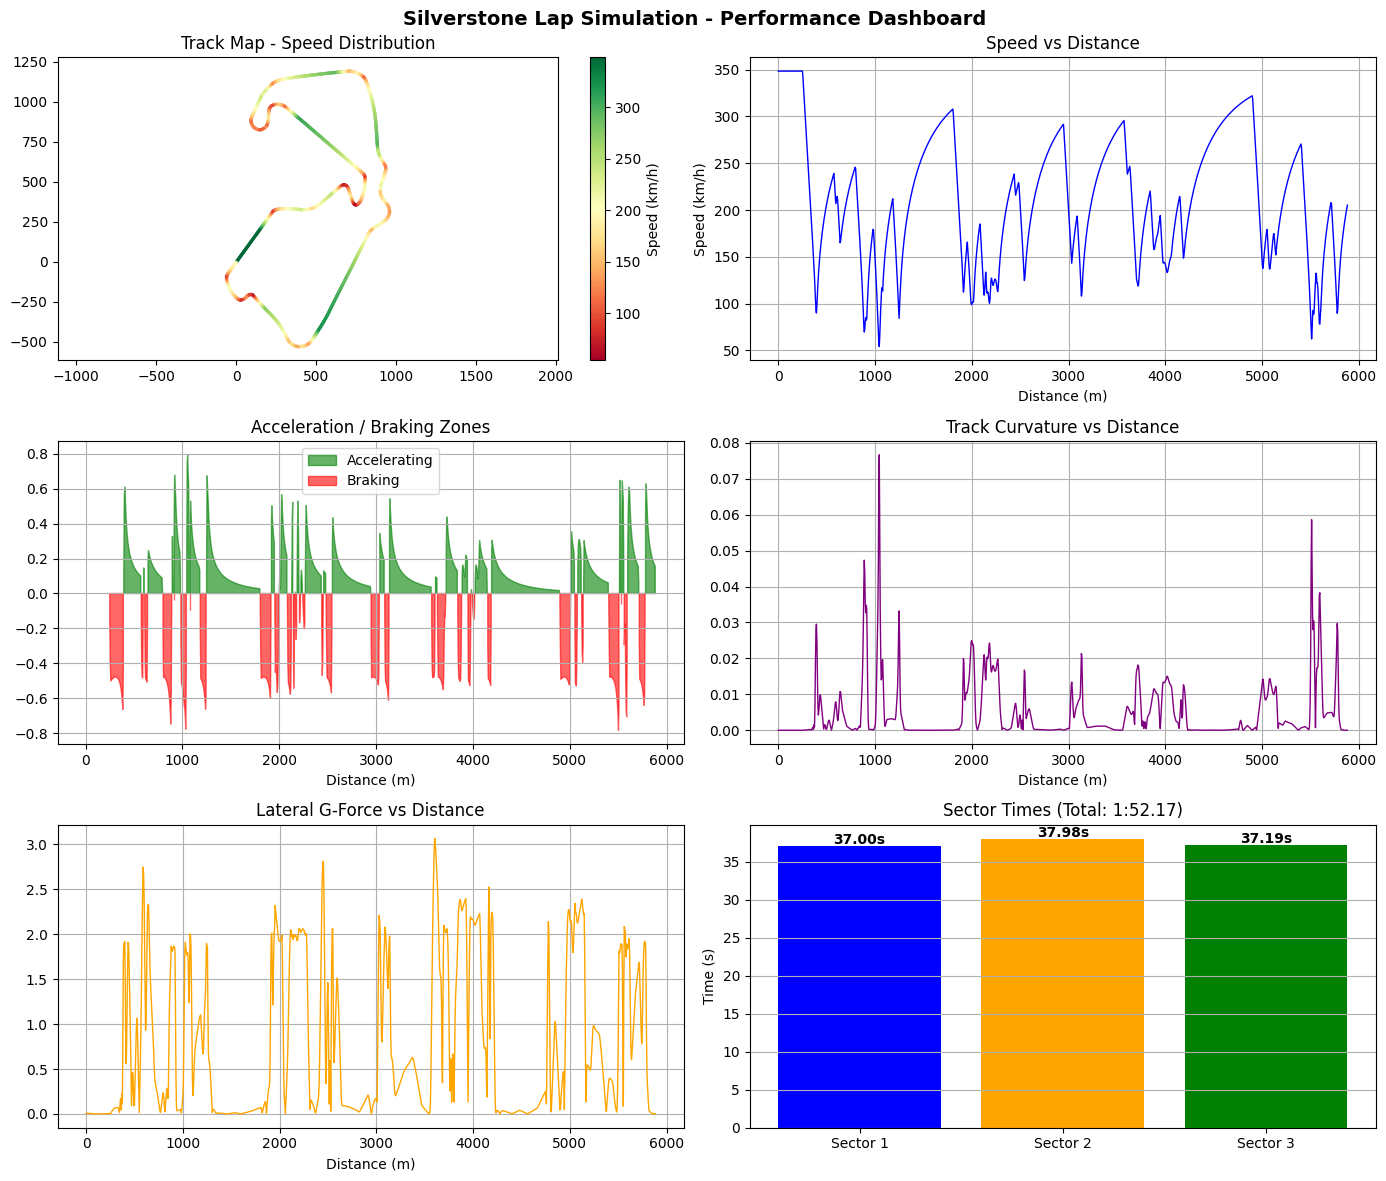

In [15]:
%matplotlib inline
import matplotlib
matplotlib.use('inline')

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Silverstone Lap Simulation - Performance Dashboard', 
             fontsize=14, fontweight='bold')

# 1. Track map coloured by speed
sc = axes[0,0].scatter(x, y, c=v*3.6, cmap='RdYlGn', s=2)
plt.colorbar(sc, ax=axes[0,0], label='Speed (km/h)')
axes[0,0].set_title('Track Map - Speed Distribution')
axes[0,0].axis('equal')

# 2. Speed vs distance
axes[0,1].plot(distance, v*3.6, 'b-', linewidth=1)
axes[0,1].set_title('Speed vs Distance')
axes[0,1].set_xlabel('Distance (m)')
axes[0,1].set_ylabel('Speed (km/h)')
axes[0,1].grid(True)

# 3. Acceleration/braking zones
acceleration = np.gradient(v, distance)
axes[1,0].fill_between(distance, acceleration, 0,
                        where=acceleration>0, color='green', alpha=0.6, label='Accelerating')
axes[1,0].fill_between(distance, acceleration, 0,
                        where=acceleration<0, color='red', alpha=0.6, label='Braking')
axes[1,0].set_title('Acceleration / Braking Zones')
axes[1,0].set_xlabel('Distance (m)')
axes[1,0].grid(True)
axes[1,0].legend()

# 4. Curvature vs distance
axes[1,1].plot(distance, curvature, 'purple', linewidth=1)
axes[1,1].set_title('Track Curvature vs Distance')
axes[1,1].set_xlabel('Distance (m)')
axes[1,1].grid(True)

# 5. Lateral G-force
lateral_g = (v**2 * curvature) / g
axes[2,0].plot(distance, lateral_g, 'orange', linewidth=1)
axes[2,0].set_title('Lateral G-Force vs Distance')
axes[2,0].set_xlabel('Distance (m)')
axes[2,0].grid(True)

# 6. Sector times
sector_size = len(dt) // 3
s1 = np.sum(dt[:sector_size])
s2 = np.sum(dt[sector_size:2*sector_size])
s3 = np.sum(dt[2*sector_size:])
axes[2,1].bar(['Sector 1', 'Sector 2', 'Sector 3'], [s1, s2, s3],
               color=['blue', 'orange', 'green'])
axes[2,1].set_title(f'Sector Times (Total: {int(lap_time//60)}:{lap_time%60:.2f})')
axes[2,1].set_ylabel('Time (s)')
for i, val in enumerate([s1, s2, s3]):
    axes[2,1].text(i, val + 0.3, f'{val:.2f}s', ha='center', fontweight='bold')
axes[2,1].grid(True, axis='y')

plt.tight_layout()
plt.show()

In [16]:
# ── PHASE 3: SENSITIVITY ANALYSIS ──

def run_lap_sim(mass, P_max, Cl, Cd, mu):
    kappa = np.maximum(curvature, 1e-6)
    numerator   = mu * mass * g
    denominator = mass * kappa - 0.5 * mu * rho * Cl * A
    v_corner = np.where(denominator > 0,
                        np.sqrt(np.maximum(numerator / denominator, 0)),
                        200.0)
    v_top = (P_max / (0.5 * rho * Cd * A))**(1/3)
    v = np.minimum(v_corner, v_top)
    
    for i in range(n-2, -1, -1):
        ds_step = distance[i+1] - distance[i]
        drag = 0.5 * rho * Cd * A * v[i+1]**2
        downforce = 0.5 * rho * Cl * A * v[i+1]**2
        normal_force = mass * g + downforce
        a_brake = (mu * normal_force + drag) / mass
        v_back = np.sqrt(v[i+1]**2 + 2 * a_brake * ds_step)
        v[i] = min(v[i], v_back)
    
    for i in range(n-1):
        ds_step = distance[i+1] - distance[i]
        drag = 0.5 * rho * Cd * A * v[i]**2
        downforce = 0.5 * rho * Cl * A * v[i]**2
        normal_force = mass * g + downforce
        F_traction = min(P_max / max(v[i], 1.0), mu * normal_force)
        a_fwd = (F_traction - drag) / mass
        v_fwd = np.sqrt(v[i]**2 + 2 * max(a_fwd, 0) * ds_step)
        v[i+1] = min(v[i+1], v_fwd)
    
    avg_v = (v[:-1] + v[1:]) / 2
    dt_lap = np.diff(distance) / np.maximum(avg_v, 1.0)
    return np.sum(dt_lap)

# Baseline
base_time = run_lap_sim(mass=798, P_max=500000, Cl=2.2, Cd=0.9, mu=1.7)
print(f"Baseline lap time: {base_time:.2f}s\n")

# Parameter sweeps (±10%)
results = {}

# Mass sensitivity
masses = np.linspace(700, 900, 10)
results['mass'] = [(m, run_lap_sim(mass=m, P_max=500000, Cl=2.2, Cd=0.9, mu=1.7)) for m in masses]

# Power sensitivity
powers = np.linspace(400000, 600000, 10)
results['power'] = [(p/1000, run_lap_sim(mass=798, P_max=p, Cl=2.2, Cd=0.9, mu=1.7)) for p in powers]

# Downforce sensitivity
cls = np.linspace(1.5, 3.0, 10)
results['Cl'] = [(c, run_lap_sim(mass=798, P_max=500000, Cl=c, Cd=0.9, mu=1.7)) for c in cls]

# Drag sensitivity
cds = np.linspace(0.6, 1.2, 10)
results['Cd'] = [(c, run_lap_sim(mass=798, P_max=500000, Cl=2.2, Cd=c, mu=1.7)) for c in cds]

print("Sensitivity analysis complete")

# ── ANSWER JADEN'S QUESTION ──
t_base    = run_lap_sim(798,    500000, 2.2, 0.9, 1.7)
t_power   = run_lap_sim(798,    520000, 2.2, 0.9, 1.7)  # +20kW
t_mass    = run_lap_sim(793,    500000, 2.2, 0.9, 1.7)  # -5kg

print(f"\nJaden's question:")
print(f"Baseline:        {t_base:.3f}s")
print(f"+20kW:           {t_power:.3f}s  (delta: {t_power-t_base:.3f}s)")
print(f"-5kg:            {t_mass:.3f}s   (delta: {t_mass-t_base:.3f}s)")
print(f"\n+20kW is worth {abs(t_power-t_base):.3f}s")
print(f"-5kg  is worth {abs(t_mass-t_base):.3f}s")
if abs(t_power-t_base) > abs(t_mass-t_base):
    print("→ +20kW gives MORE lap time than saving 5kg")
else:
    print("→ Saving 5kg gives MORE lap time than +20kW")

Baseline lap time: 112.17s

Sensitivity analysis complete

Jaden's question:
Baseline:        112.173s
+20kW:           111.579s  (delta: -0.594s)
-5kg:            112.054s   (delta: -0.120s)

+20kW is worth 0.594s
-5kg  is worth 0.120s
→ +20kW gives MORE lap time than saving 5kg


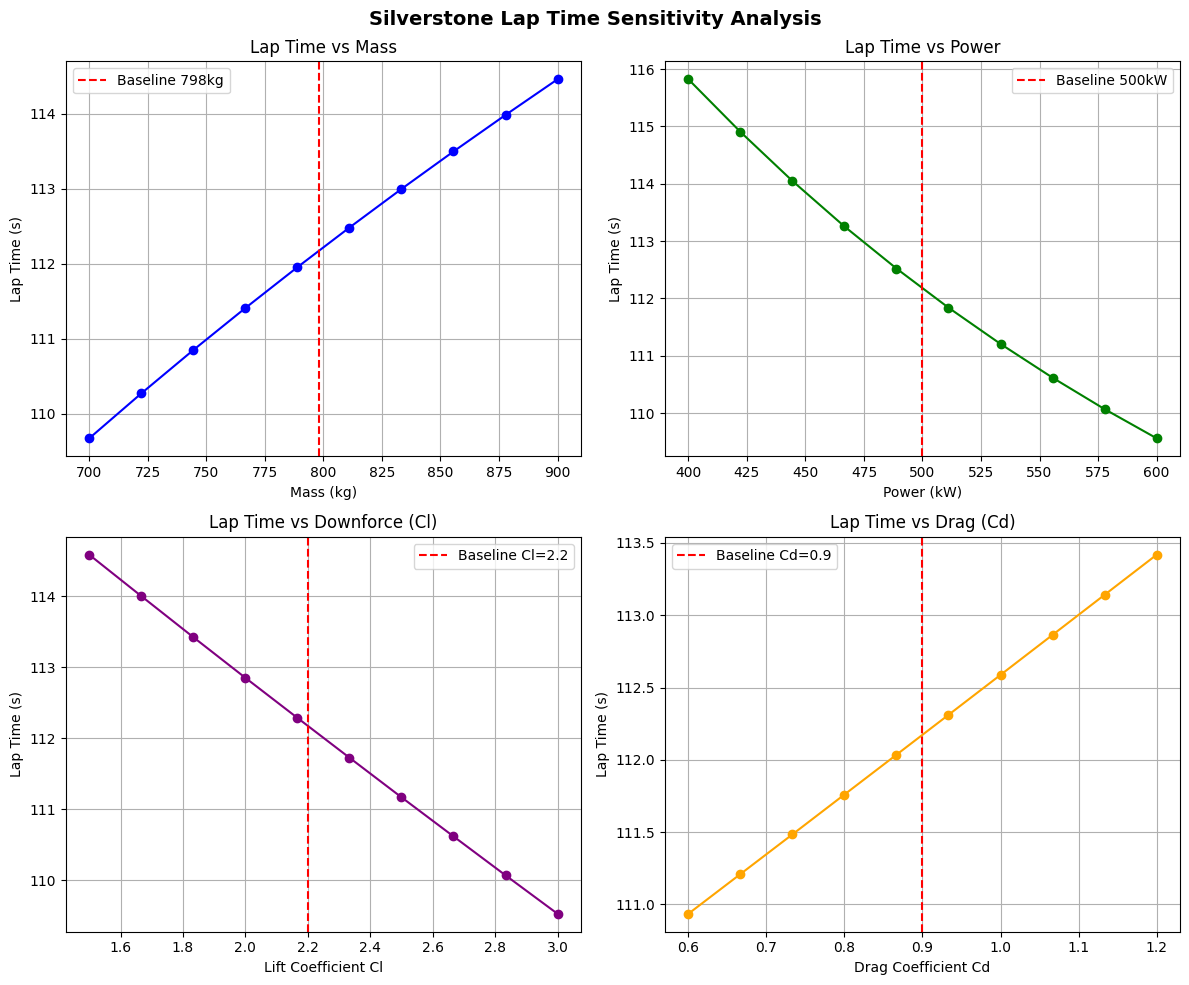

Sensitivity plot saved


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Silverstone Lap Time Sensitivity Analysis', fontsize=14, fontweight='bold')

# Mass
m_vals, m_times = zip(*results['mass'])
axes[0,0].plot(m_vals, m_times, 'b-o')
axes[0,0].axvline(x=798, color='r', linestyle='--', label='Baseline 798kg')
axes[0,0].set_title('Lap Time vs Mass')
axes[0,0].set_xlabel('Mass (kg)')
axes[0,0].set_ylabel('Lap Time (s)')
axes[0,0].grid(True)
axes[0,0].legend()

# Power
p_vals, p_times = zip(*results['power'])
axes[0,1].plot(p_vals, p_times, 'g-o')
axes[0,1].axvline(x=500, color='r', linestyle='--', label='Baseline 500kW')
axes[0,1].set_title('Lap Time vs Power')
axes[0,1].set_xlabel('Power (kW)')
axes[0,1].set_ylabel('Lap Time (s)')
axes[0,1].grid(True)
axes[0,1].legend()

# Downforce
cl_vals, cl_times = zip(*results['Cl'])
axes[1,0].plot(cl_vals, cl_times, 'purple', marker='o')
axes[1,0].axvline(x=2.2, color='r', linestyle='--', label='Baseline Cl=2.2')
axes[1,0].set_title('Lap Time vs Downforce (Cl)')
axes[1,0].set_xlabel('Lift Coefficient Cl')
axes[1,0].set_ylabel('Lap Time (s)')
axes[1,0].grid(True)
axes[1,0].legend()

# Drag
cd_vals, cd_times = zip(*results['Cd'])
axes[1,1].plot(cd_vals, cd_times, 'orange', marker='o')
axes[1,1].axvline(x=0.9, color='r', linestyle='--', label='Baseline Cd=0.9')
axes[1,1].set_title('Lap Time vs Drag (Cd)')
axes[1,1].set_xlabel('Drag Coefficient Cd')
axes[1,1].set_ylabel('Lap Time (s)')
axes[1,1].grid(True)
axes[1,1].legend()

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sensitivity plot saved")